In [1]:
%run "../../ehm_ed/src/module_Data.py"
%run "../../ehm_ed/src/module_Plots_Phase_Diagram.py"
# %matplotlib qt5 
%matplotlib inline

import numpy as np
import pandas as pd

theme = "hot"
levels = 50

def get_df_quantity(df, value_name, x = "U", y = "V"):
    return df.pivot(index=y, columns = x, values=value_name).to_numpy()

In [2]:
# Parameters
L = 5

In [3]:
path_scalar = "../results/EHM_ITensor_L=5_U0=-6.00_Uf=6.00_V0=-6.00_Vf=6.00_NPoints=100_scalar.csv"
path_vector =  "../results/EHM_ITensor_L=5_U0=-6.00_Uf=6.00_V0=-6.00_Vf=6.00_NPoints=100_vectors.csv"

df_scalar = pd.read_csv(path_scalar)
df_vec = pd.read_csv(path_vector)

U = np.sort(df_scalar["U"].unique())
V = np.sort(df_scalar["V"].unique())

In [4]:
df_scalar["von_neumann_2rdm_GS"]

0       0.063693
1       0.253153
2       0.022964
3       0.009565
4       0.008283
          ...   
9995    0.041028
9996    0.038046
9997    0.035333
9998    0.032864
9999    0.030613
Name: von_neumann_2rdm_GS, Length: 10000, dtype: float64

## Plots for scalar quantities

In [5]:
df_scalar.keys()

Index(['U', 'quantum_coherence_1rdm_GS', 'energy_GS', 'V',
       'quantum_coherence_2rdm_GS', 'von_neumann_1rdm_GS',
       'von_neumann_2rdm_GS'],
      dtype='str')

In [6]:
data_scalar = dict.fromkeys(df_scalar.keys())

for key in data_scalar.keys():
    data_scalar[key] = get_df_quantity(df_scalar, key)

Text(0.5, 0.98, 'Normalized $S_{1}(\\hat{\\rho})$')

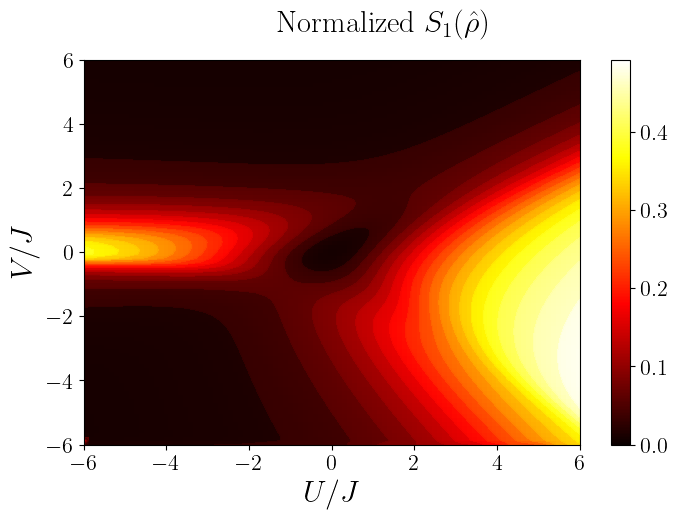

In [7]:
max_svn_1rdm = np.log(2)

Svn_1rdm = data_scalar["von_neumann_1rdm_GS"]
# Svn_1rdm /= max_svn_1rdm

fig, ax = get_2d_heatmap(Svn_1rdm, U, V, vmin=0.0, theme = theme)
fig.suptitle(r"Normalized $S_{1}(\hat{\rho})$", fontsize = 22)

Text(0.5, 0.98, 'Normalized $S_{2}(\\hat{\\rho})$')

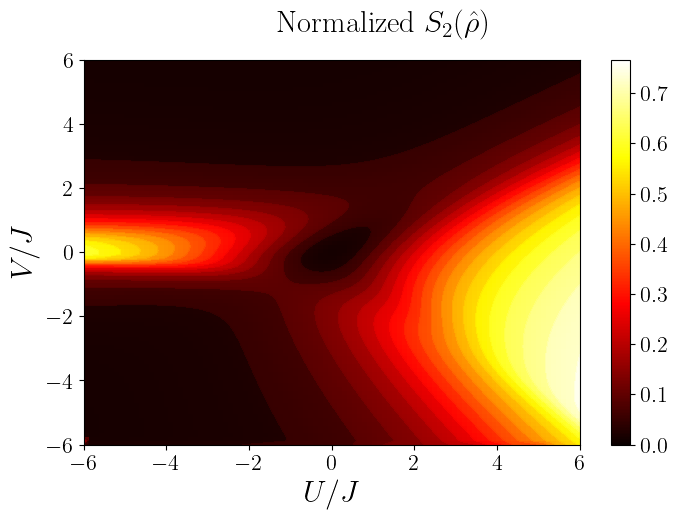

In [8]:
max_svn_2rdm = np.log(2) + np.log((2*L-1)/(L-1))

Svn_2rdm = data_scalar["von_neumann_2rdm_GS"]

fig, ax = get_2d_heatmap(Svn_2rdm, U, V, vmin=0.0, theme = theme)
fig.suptitle(r"Normalized $S_{2}(\hat{\rho})$", fontsize = 22)

Text(0.5, 0.98, '$\\mathcal{C}_{\\ell}(\\hat{{\\rho}_2})$')

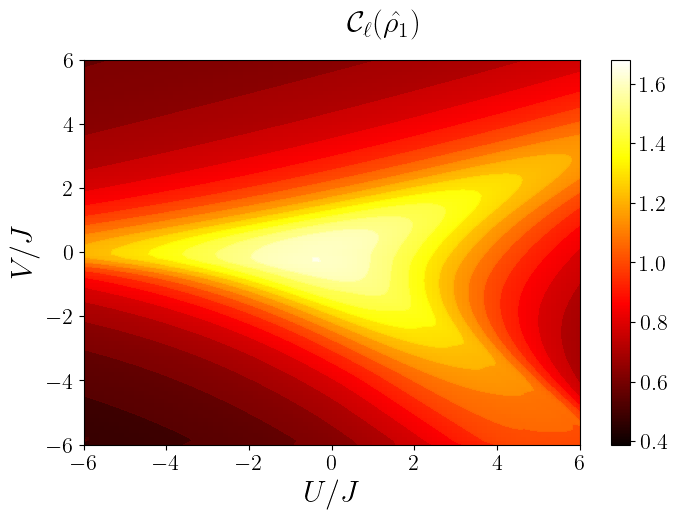

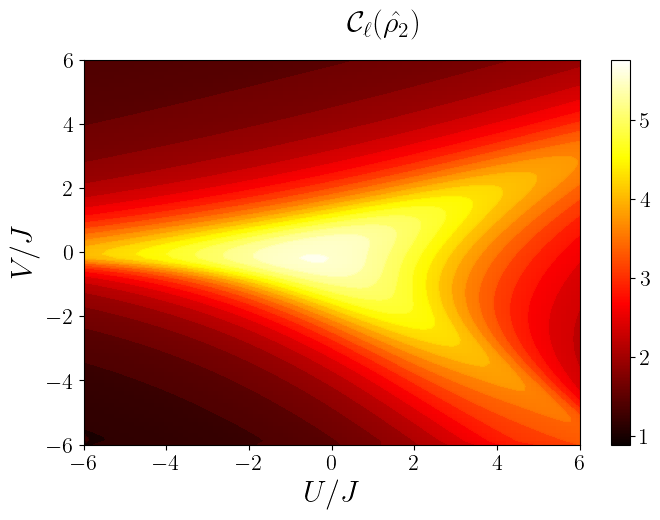

In [9]:
quantum_coherence_1rdm = data_scalar["quantum_coherence_1rdm_GS"]
fig, ax = get_2d_heatmap(quantum_coherence_1rdm, U, V, theme = theme)
fig.suptitle(r"$\mathcal{C}_{\ell}(\hat{{\rho}_1})$", fontsize = 22)

quantum_coherence_2rdm = data_scalar["quantum_coherence_2rdm_GS"]
fig, ax = get_2d_heatmap(quantum_coherence_2rdm, U, V, theme = theme)
fig.suptitle(r"$\mathcal{C}_{\ell}(\hat{{\rho}_2})$", fontsize = 22)

## Plots for vector quantities

### Order parameters

In [10]:
df_mag = df_vec.query("observable == 'magnetization_GS'")
df_den = df_vec.query("observable == 'charge_density_GS'")

def m_SDW_from_df(group):
    Sj = group.sort_values("site")["value"].to_numpy()
    L = len(Sj)
    return np.sum(((-1) ** np.arange(L)) * Sj) / L

def m_CDW_from_df(group):
    nj = group.sort_values("site")["value"].to_numpy()
    L = len(nj)
    return np.sum(((-1) ** np.arange(L)) * (nj - 1.0)) / L

m_sdw = (df_mag.groupby(["U", "V"]).apply(m_SDW_from_df).reset_index(name="m_SDW"))
m_cdw = (df_den.groupby(["U", "V"]).apply(m_CDW_from_df).reset_index(name="m_CDW"))


df_order_parameters = pd.merge(m_sdw, m_cdw, on=["U", "V"])


U_vals = np.sort(df_order_parameters["U"].unique())
V_vals = np.sort(df_order_parameters["V"].unique())

Z_sdw = df_order_parameters.pivot(index="V", columns="U",values="m_SDW").to_numpy()
Z_cdw = df_order_parameters.pivot(index="V", columns="U",values="m_CDW").to_numpy()

# masks for first quadrant
mask_U = U_vals >= 0
mask_V = V_vals >= 0

U_pos = U_vals[mask_U]
V_pos = V_vals[mask_V]

Z_sdw_pos = Z_sdw[np.ix_(mask_V, mask_U)]
Z_cdw_pos = Z_cdw[np.ix_(mask_V, mask_U)]

Text(0, 0.5, '$V/J$')

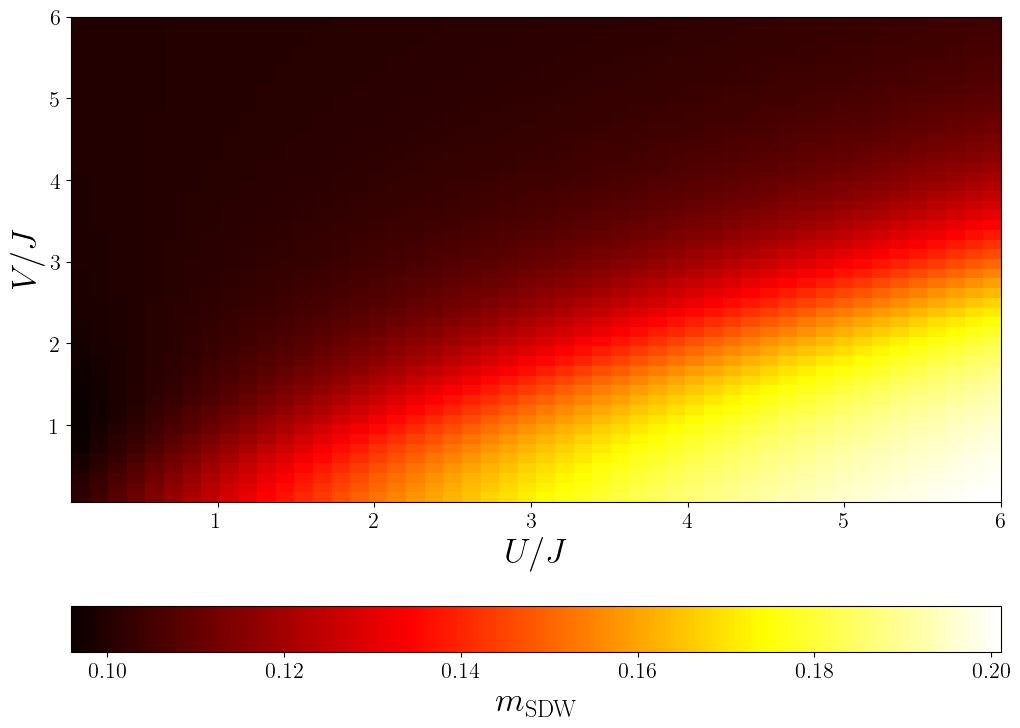

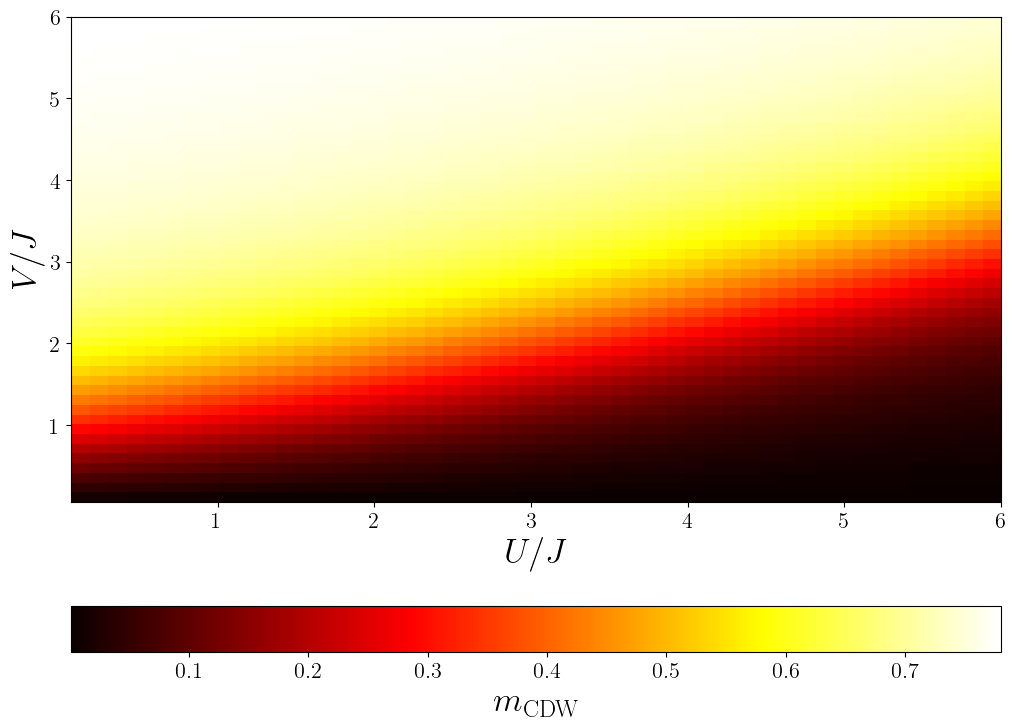

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
im = ax.imshow(Z_sdw_pos,origin="lower",aspect="auto",extent=[U_pos.min(), U_pos.max(), V_pos.min(), V_pos.max()], cmap = theme)
# cbar = fig.colorbar(im, label=r"$m_{\mathrm{SDW}}$")
cbar = fig.colorbar(im, ax=ax, cmap=theme, orientation="horizontal")
cbar.set_label(r"$m_{\mathrm{SDW}}$", fontsize = 25)
ax.set_xlabel(r"$U/J$", fontsize = 25)
ax.set_ylabel(r"$V/J$", fontsize = 25)

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
im = ax.imshow(Z_cdw_pos,origin="lower",aspect="auto",extent=[U_pos.min(), U_pos.max(), V_pos.min(), V_pos.max()], cmap = theme)
cbar = fig.colorbar(im, ax=ax, cmap=theme, orientation="horizontal")
cbar.set_label(r"$m_{\mathrm{CDW}}$", fontsize = 25)
ax.set_xlabel(r"$U/J$", fontsize = 25)
ax.set_ylabel(r"$V/J$", fontsize = 25)

### Single site entanglement

Text(0.5, 1.0, 'Average single-site entanglement')

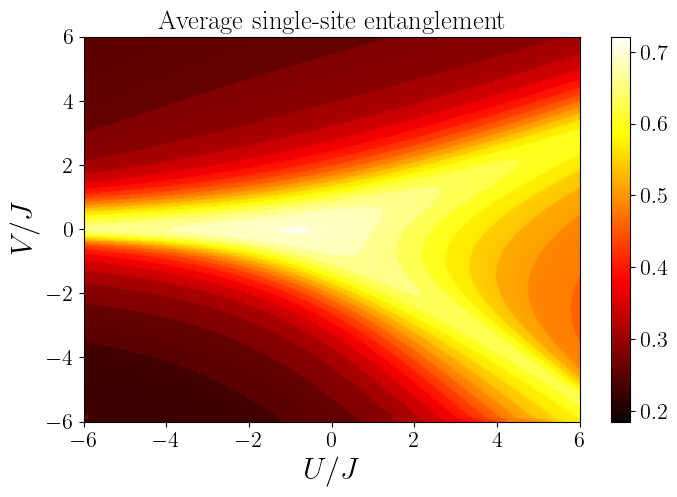

In [12]:
df_single_site_entanglement = df_vec.query("observable == 'single_site_entanglement_GS'")

df_avg = (df_single_site_entanglement.groupby(["U", "V"])["value"].mean().reset_index(name="S_avg"))


S_avg_grid = (df_avg.pivot(index="V", columns="U", values="S_avg").to_numpy())

fig, ax = get_2d_heatmap(quantity=S_avg_grid, x=U_vals, y=V_vals, xlabel=r"$U/J$", ylabel=r"$V/J$", theme=theme)
ax.set_title("Average single-site entanglement")

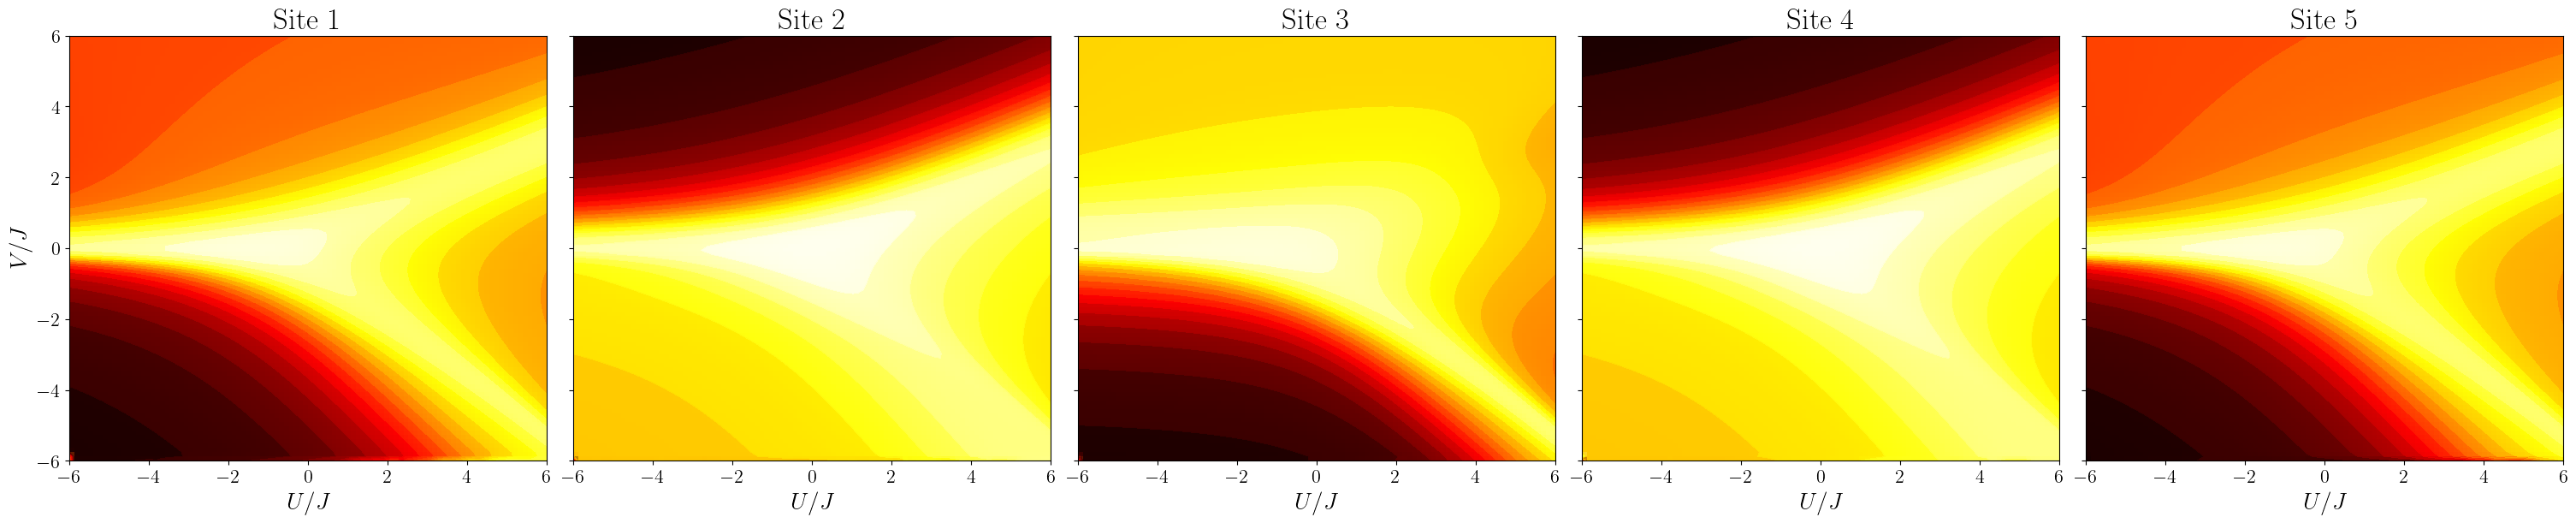

In [13]:
def site_phase_grid(df, site):
    df_site = df.query("site == @site")
    Z = (df_site.pivot(index="V", columns="U", values="value").to_numpy())
    return Z

from matplotlib.colors import Normalize
def plot_site_resolved_phase_diagrams(
    df,
    U_vals,
    V_vals,
    theme="inferno",
    vmin=None,
    vmax=None,
    levels=20,
):
    sites = np.sort(df["site"].unique())
    L = len(sites)

    # Build all grids first (important for shared vmin/vmax)
    grids = [site_phase_grid(df, s) for s in sites]

    if vmin is None:
        vmin = np.nanmin(grids)
    if vmax is None:
        vmax = np.nanmax(grids)

    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(1, L,
        figsize=(6 * L, 6), sharey=True,
        constrained_layout=True)

    if L == 1:
        axes = [axes]

    for ax, site, Z in zip(axes, sites, grids):

        im = ax.imshow(
            Z,
            origin="lower",
            aspect="auto",
            cmap=theme,
            norm=norm,
            extent=[U_vals.min(), U_vals.max(), V_vals.min(), V_vals.max()],
        )

        X, Y = np.meshgrid(U_vals, V_vals)
        ax.contourf(X, Y, Z,
            levels=levels,
            cmap=theme,
            alpha=0.7,)
        
        ax.set_title(f"Site {site}", fontsize=25)
        ax.set_xlabel(r"$U/J$", fontsize = 20)

    axes[0].set_ylabel(r"$V/J$", fontsize = 20)

    return fig, axes

fig, axes = plot_site_resolved_phase_diagrams(df_single_site_entanglement, U_vals, V_vals, theme=theme)

## Plots for entanglement spectrum

The entanglement spectrum is given by 
$$ \Omega = \xi_2 - \xi_1 $$

where $\xi_i \leq \xi_{i+1}$.

In [14]:
keys = df_vec["observable"].unique()

df_entanglement_spectrums = []

i = 1 
j = 0

print(keys)
for key in keys:
    df_entanglement_spectrums.append(df_vec.query(f"observable == '{key}'"))

def entanglement_gap(group, i, j):
    eps = (group.sort_values("site")["value"].to_numpy())

    if len(eps) < 2:
        return np.nan 
    
    return eps[i] - eps[j]

df_gap_1rdm = (df_entanglement_spectrums[0].groupby(["U", "V"]).apply(entanglement_gap, i = 1, j = 0).reset_index(name="Omega"))
df_gap_2rdm = (df_entanglement_spectrums[1].groupby(["U", "V"]).apply(entanglement_gap, i = 1, j = 0).reset_index(name="Omega"))

U_vals = np.sort(df_gap_1rdm["U"].unique())
V_vals = np.sort(df_gap_1rdm["V"].unique())

Omega_grid_1rdm = (df_gap_1rdm.pivot(index="V", columns="U", values="Omega").to_numpy())
Omega_grid_2rdm = (df_gap_2rdm.pivot(index="V", columns="U", values="Omega").to_numpy())

assert Omega_grid_1rdm.shape == (len(V_vals), len(U_vals))
assert Omega_grid_2rdm.shape == (len(V_vals), len(U_vals))

<StringArray>
[  'single_site_entanglement_GS',                   'doublons_GS',
 'entanglement_spectrum_2rdm_GS', 'entanglement_spectrum_1rdm_GS',
              'magnetization_GS',             'charge_density_GS']
Length: 6, dtype: str


Text(0.5, 1.0, 'Entanglement gap $\\Omega_2 = \\varepsilon_1 - \\varepsilon_0$')

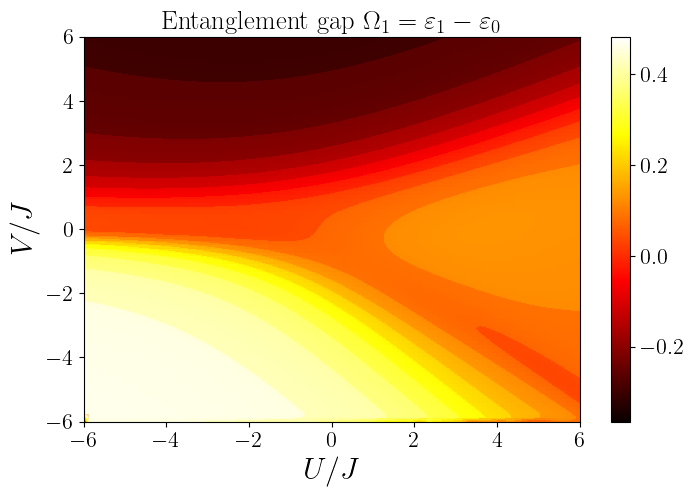

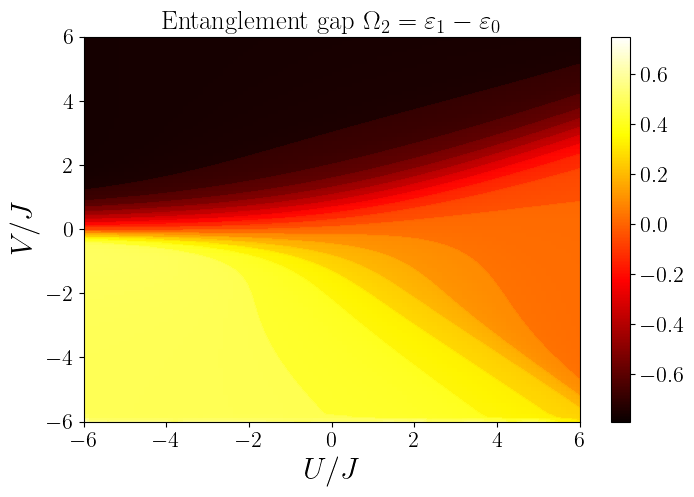

In [20]:
fig, ax = get_2d_heatmap(quantity=Omega_grid_1rdm, x=U_vals, y=V_vals, xlabel=r"$U/J$", ylabel=r"$V/J$", theme = theme)
ax.set_title(fr"Entanglement gap $\Omega_1 = \varepsilon_{i} - \varepsilon_{j}$")
fig, ax = get_2d_heatmap(quantity=Omega_grid_2rdm, x=U_vals, y=V_vals, xlabel=r"$U/J$", ylabel=r"$V/J$", theme = theme)
ax.set_title(fr"Entanglement gap $\Omega_2 = \varepsilon_{i} - \varepsilon_{j}$")
# fig, ax = get_2d_heatmap(quantity=np.log10(Omega_grid_1rdm), x=U_vals, y=V_vals, xlabel=r"$U/J$", ylabel=r"$V/J$", theme = theme)
# ax.set_title(r"$\ln_{{10}} \Omega_1$")
# fig, ax = get_2d_heatmap(quantity=np.log10(Omega_grid_2rdm), x=U_vals, y=V_vals, xlabel=r"$U/J$", ylabel=r"$V/J$", theme = theme)
# ax.set_title(r"$\ln_{{10}} \Omega_2$")

### Plots of cuts in the phase diagrams

In [16]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

def plot_phase_cut(
    quantities,        # list of 2D arrays
    labels,            # list of strings
    U_vals,
    V_vals,
    target,
    cut="vertical",
    ylabel=r"$\Omega$",
    colors=None,
    phase_boundaries=None,
    # [(value, "Phase name"), ...]
):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    fig.subplots_adjust(top=0.82)

    if colors is None:
        colors = [f"C{i}" for i in range(len(quantities))]

    for quantity, label, color in zip(quantities, labels, colors):

        if cut == "vertical":
            iU = np.argmin(np.abs(U_vals - target))
            x = V_vals
            y = quantity[:, iU]
            ax.set_xlabel(r"$V/J$", fontsize = 25)
        elif cut == "horizontal":
            iV = np.argmin(np.abs(V_vals - target))
            x = U_vals
            y = quantity[iV, :]
            ax.set_xlabel(r"$U/J$", fontsize = 25)
        else:
            raise ValueError("cut must be 'vertical' or 'horizontal'")

        ax.plot(x, y, lw=2, color=color, label=label)

    ax.set_ylabel(ylabel, fontsize = 25)
    ax.legend(fontsize = 20)

    if phase_boundaries is not None:

        numeric_boundaries = [(v, n) for v, n in phase_boundaries if v is not None]
        numeric_boundaries = sorted(numeric_boundaries, key=lambda x: x[0])

        fig.canvas.draw()

        x_min, x_max = ax.get_xlim()
        regions = [x_min] + [b[0] for b in numeric_boundaries] + [x_max]
        names = [b[1] for b in phase_boundaries]

        colors_phases = plt.cm.hot(np.linspace(0, 0.75, len(names)))

        band_bottom = 1.02
        band_height = 0.08

        for i, name in enumerate(names):

            x0 = (regions[i] - x_min) / (x_max - x_min)
            x1 = (regions[i+1] - x_min) / (x_max - x_min)

            rect = Rectangle(
                (x0, band_bottom),
                x1 - x0,
                band_height,
                transform=ax.transAxes,
                color=colors_phases[i],
                alpha=0.6,
                ec="black",
                lw=0.8,
                clip_on=False,
            )
            ax.add_patch(rect)

            ax.text(
                (x0 + x1) / 2,
                band_bottom + band_height / 2,
                name,
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=14,
                weight="bold",
            )
    return fig, ax

In [ ]:
boundaries_hor = [  (-1.5, "SS"),
                    (0.0, "TS"),
                    (None, "CDW")
            ]
boundaries_vert = [ (-1.5, "PS"),
                    (0.0, "TS"),
                    (None, "CDW")
            ]

colors=["black", "blue"]

def plot_set_cuts(target, boundaries, colors):

    plot_phase_cut(
        quantities=[Omega_grid_1rdm, Omega_grid_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="horizontal",
        labels=[r"$\Omega_{1}$", r"$\Omega_{2}$"],
        ylabel = "Entanglement gap",
        colors=colors, 
        phase_boundaries=boundaries_hor)

    plot_phase_cut(
        quantities=[Omega_grid_1rdm, Omega_grid_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="vertical",
        labels=[r"$\Omega_{1}$", r"$\Omega_{2}$"],
        colors=colors, 
        ylabel = "Entanglement gap",
        phase_boundaries=boundaries_vert)

    plot_phase_cut(
        quantities=[Svn_1rdm, Svn_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="horizontal",
        labels=[r"$S_1(\hat{{\rho}_1})$", r"$S_2(\hat{{\rho}_2})$"],
        colors=colors, 
        ylabel = "Entanglement entropy",
        phase_boundaries=boundaries_hor)

    plot_phase_cut(
        quantities=[Svn_1rdm, Svn_2rdm, quantum_coherence_1rdm, quantum_coherence_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="vertical",
        labels=[r"$S_1(\hat{{\rho}_1})$", r"$S_2(\hat{{\rho}_2})$"],
        colors=colors, 
        ylabel = "Entanglement entropy",
        phase_boundaries=boundaries_vert)

    plot_phase_cut(
        quantities=[quantum_coherence_1rdm, quantum_coherence_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="horizontal",
        labels=[r"$\mathcal{C}_{\ell}(\hat{{\rho}_1})$", r"$\mathcal{C}_{\ell}(\hat{{\rho}_2})$"],
        colors=colors, 
        ylabel = "Quantum coherence",
        phase_boundaries=boundaries_hor)

    plot_phase_cut(
        quantities=[quantum_coherence_1rdm, quantum_coherence_2rdm],
        U_vals=U_vals,
        V_vals=V_vals,
        target=target,
        cut="vertical",
        labels=[r"$\mathcal{C}_{\ell}(\hat{{\rho}_1})$", r"$\mathcal{C}_{\ell}(\hat{{\rho}_2})$"],
        colors=colors, 
        ylabel = "Quantum coherence",
        phase_boundaries=boundaries_vert)

### target = 0.0

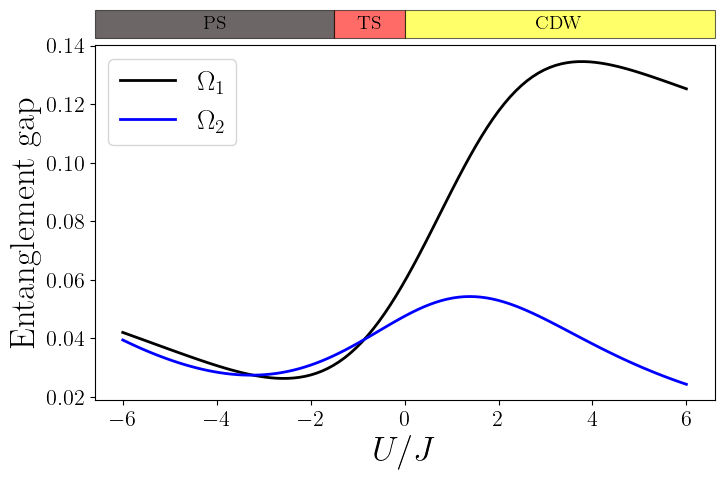

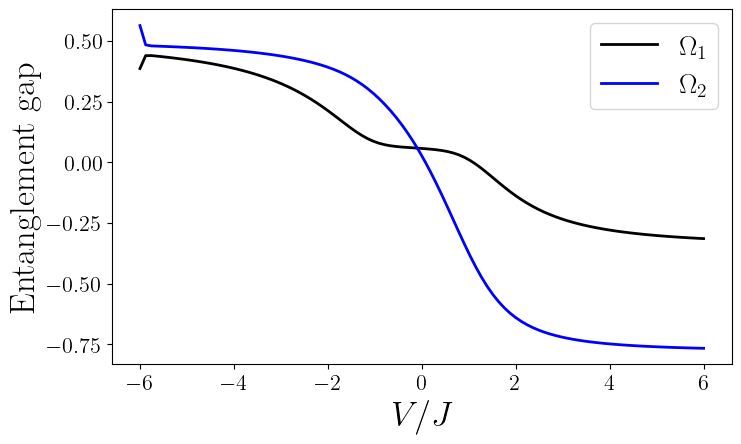

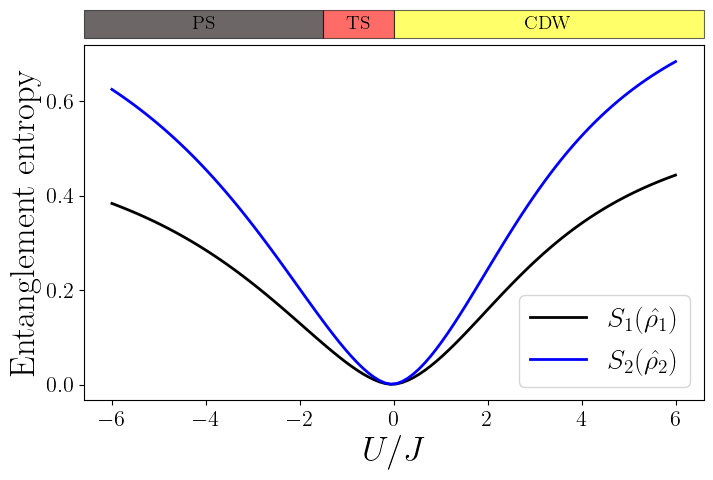

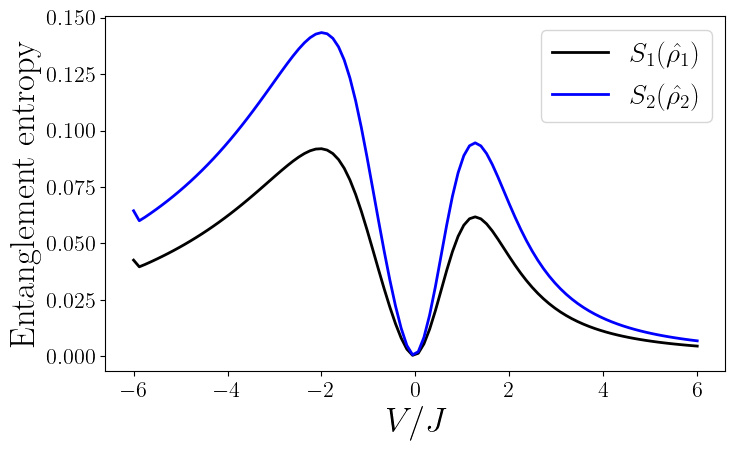

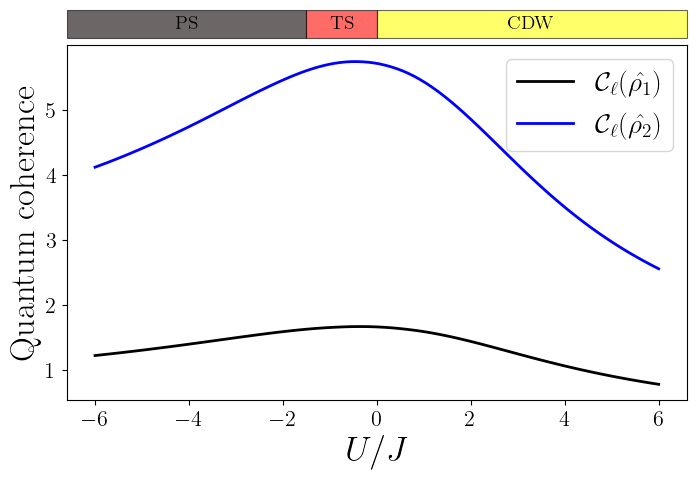

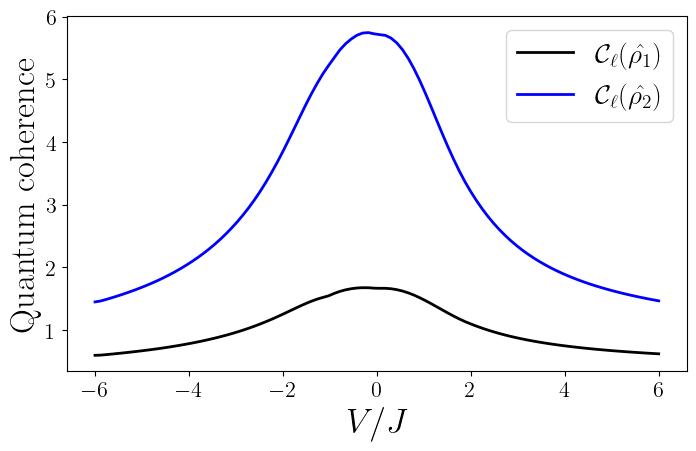

In [18]:
plot_set_cuts(0.0, boundaries, colors)

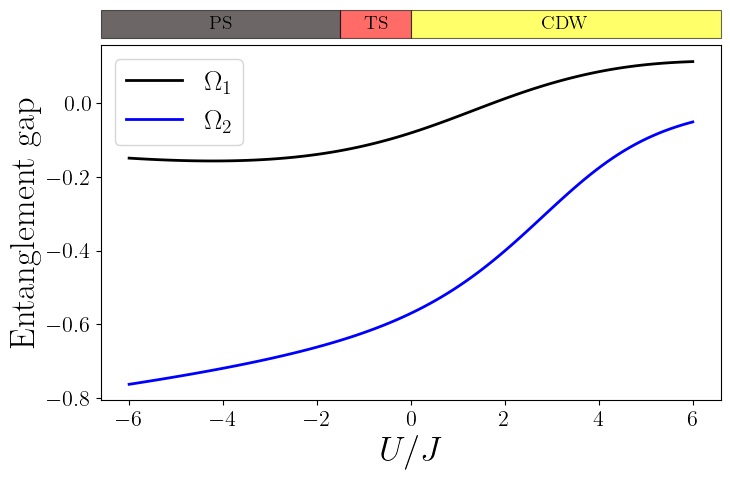

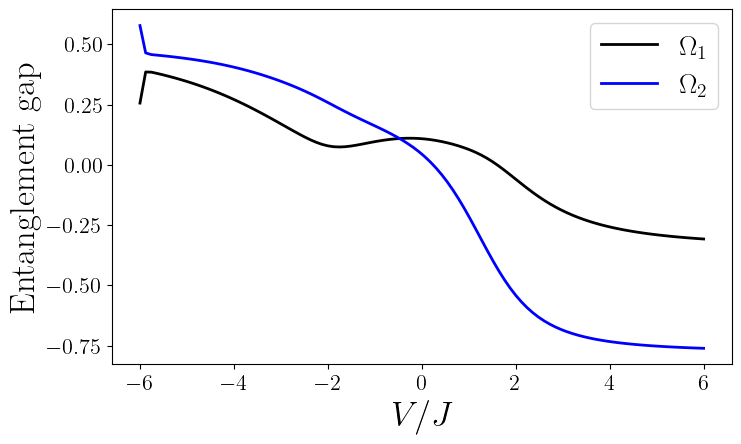

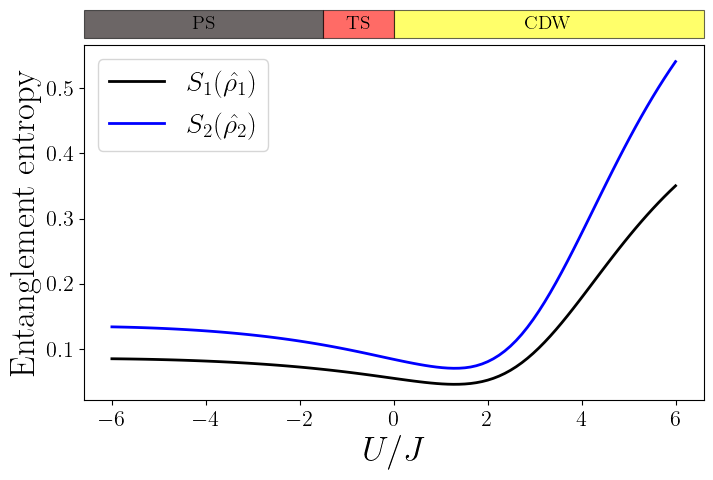

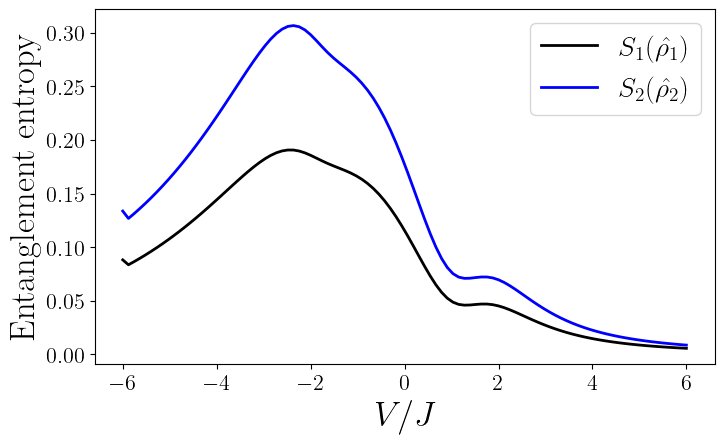

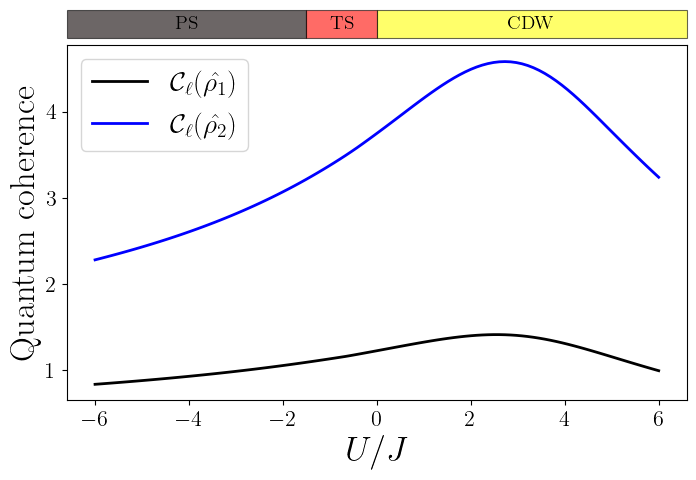

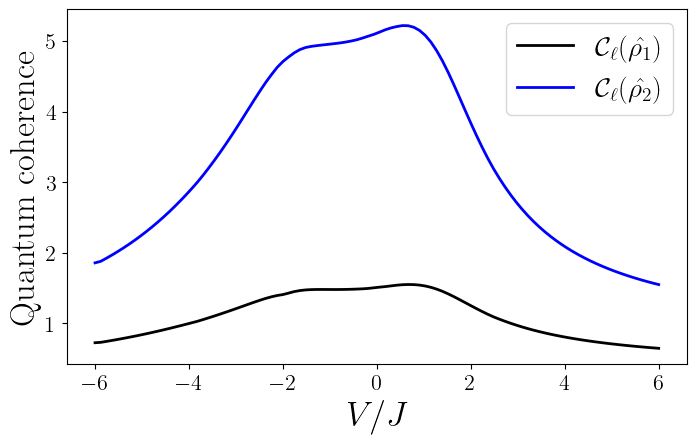

In [24]:
plot_set_cuts(1.6, boundaries, colors)